### Importing the Libraries

In [20]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn.functional as F

# Root data directory path

In [21]:
data_dir = r"D:\signatureRecognition\notebook\data"

# Total number of classes

In [22]:
clas_name = os.listdir(data_dir)
len(clas_name)

2

In [23]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torchvision import transforms as T, datasets

# Checking the CUDA availibilty

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:{}".format(device))

Device:cpu


# Transforming the data

In [25]:
data_transform = T.Compose([
    T.Resize(size=(224,224)),
    T.RandomRotation(degrees=(-20,+20)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [26]:
data = datasets.ImageFolder(data_dir, transform=data_transform)
total_count = len(data)

In [27]:
total_count

2606

In [28]:
data.classes

['full_forg', 'full_org']

# Spliting the Data

In [29]:
train_count = int(0.6 * total_count)
valid_count = int(0.3 * total_count)
test_count = total_count - train_count - valid_count
train_data, val_data, test_data = torch.utils.data.random_split(data, (train_count, valid_count, test_count))

In [31]:
len(train_data)

1563

In [32]:
train_data.dataset

Dataset ImageFolder
    Number of datapoints: 2606
    Root location: D:\signatureRecognition\notebook\data
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

# Defining the functions

In [ ]:
def show_image(image, label, get_denormalize =True):

    image = image.permute(1,2,0)
    mean = torch.FloatTensor([0.485,0.456,0.406])
    std = torch.FloatTensor([0.229,0.224,0.225])

    if get_denormalize == True:
        image = image*std + mean
        image = np.clip(image, 0,1)
        plt.imshow(image)
        plt.title(label)
    else:
        plt.imshow(image)
        plt.title(label)

# def show_grid(image, title=None):

#     image = image.permute(1,2,0)
#     mean = torch.FloatTensor([0.485,0.456,0.406])
#     std = torch.FloatTensor([0.229,0.224,0.225])

#     image = image*std + mean
#     image = np.clip(image, 0,1)

#     plt.figure(figsize=[15,15])
#     plt.imshow(image)
#     if title != None:
#         plt.title(title)

def accuracy(y_pred, y_true):
    y_pred = F.softmax(y_pred, dim=1)
    top_p, top_class = y_pred.topk(1,dim=1)
    equals = top_class == y_true.view(*top_class.shape)
    return torch.mean(equals.type(torch.FloatTensor))

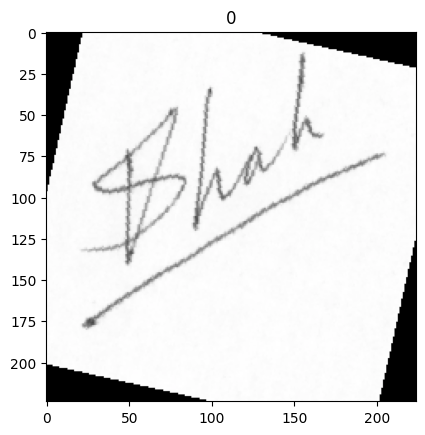

In [37]:
img, label = train_data[0]
show_image(img, label)


# DataLoader

In [39]:
trainloader = DataLoader(train_data, batch_size=32, shuffle=True)
print("No. of batchs in trainloader:{}".format(len(trainloader)))
print("No. of Total examples:{}".format(len(trainloader.dataset)))

validationloader = DataLoader(val_data, batch_size=32, shuffle=True)
print("No. of batchs in validationloader:{}".format(len(validationloader)))
print("No. of Total examples:{}".format(len(validationloader.dataset)))

testloader = DataLoader(test_data, batch_size=32, shuffle=False)
print("No. of batchs in testloader:{}".format(len(testloader)))
print("No. of Total examples:{}".format(len(testloader.dataset)))


No. of batchs in trainloader:49
No. of Total examples:1563
No. of batchs in validationloader:25
No. of Total examples:781
No. of batchs in testloader:9
No. of Total examples:262


# Model

In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models
import torchvision.transforms as transforms


In [42]:
model = models.resnet34(pretrained=True)

c:\Users\hp\anaconda3\envs\signatureRecognition\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\hp\anaconda3\envs\signatureRecognition\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to C:\Users\hp/.cache\torch\hub\checkpoints\resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:31<00:00, 2.74MB/s]


In [43]:
model.fc = nn.Sequential(
    nn.Dropout(0,1),
    nn.Linear(model.fc.in_features, len(clas_name))
)
model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

In [44]:
def train(model, criterion, optimizer, train_datalodaer, test_dataloader):

    total_train_loss = 0
    total_test_loss  = 0
    model.train()
    with tqdm(train_datalodaer, unit='batch', leave=False) as pbar:
        pbar.set_description(f'training')
        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)
            output= model(images)

            loss = criterion(output, idxs)
            total_train_loss += loss.item()

            loss.backward()
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

    model.eval()
    with tqdm(test_dataloader, unit='batch', leave=False) as pbar:
        pbar.set_description(f'testing')
        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)
            output= model(images)

            loss = criterion(output, idxs)
            total_test_loss += loss.item()
    
    train_acc = total_train_loss / len(train_data)
    test_acc = total_test_loss / len(val_data)
    print(f"Train loss: {train_acc: .4f} Test Loss: {test_acc: .4f}")



In [45]:
%%time
epochs = 2
for i in range(epochs):
    print(f"Epoch {i+1}/{epochs}")
    train(model, criterion, optimizer, trainloader, validationloader)

Epoch 1/2


Train loss:  0.0061 Test Loss:  0.0054
Epoch 2/2


Train loss:  0.0008 Test Loss:  0.0010
CPU times: total: 42min 22s
Wall time: 11min 5s


# Model Saving

In [48]:
Path =  r'd:\\signatureRecognition\\notebook\\model.pt'
torch.save(model, Path)

In [47]:
pwd

'd:\\signatureRecognition\\notebook'

# Loading torch model

In [49]:
# Model class must be defined somewhere
model = torch.load(Path)
model.eval()

C:\Users\hp\AppData\Local\Temp\ipykernel_18296\424075518.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(Path)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# Model Evaluation

In [50]:
def evaluate(model, criterion, optimizer, test_dataloader):
    total_test_loss = 0

    model.eval()
    with tqdm(test_dataloader, unit='batch', leave=False) as pbar:
        pbar.set_description(f'testing')
        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)
            output= model(images)

            loss = criterion(output, idxs)
            total_test_loss += loss.item()
    
    test_acc = total_test_loss / len(val_data)
    print(f"Test loss: {test_acc:.4f}")

In [51]:
evaluate(model, criterion, optimizer, testloader)

Test loss: 0.0003


# Prediction

In [57]:
label_names = data.classes
label_names

['full_forg', 'full_org']

In [60]:
from PIL import Image

image = Image.open(r"D:\signatureRecognition\notebook\data\full_org\original_1_2.png")
preprocess = transforms.Compose(
    [transforms.Resize(size=(224,224)),
    transforms.Grayscale(3),
    transforms.ToTensor()]
)

image = preprocess(image)
image = image[:3]

image = image.unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(image)
    probs = torch.softmax(logits, dim=1)
    pred_label = torch.argmax(probs, dim=1)

print(f"Predicted Label: {pred_label.item()}")

predicted_class_name = label_names[pred_label.item()]

print(f"Predicted class name: {predicted_class_name}")

Predicted Label: 1
Predicted class name: full_org
